In [5]:
import pandas as pd
df = pd.read_excel('./data/apt_seoul.xlsx',skiprows=12, thousands=",")
#ctrl + shift + - 하면 나눠짐 대박~

C:\Users\MBC\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [6]:
# 불편한 칼럼이름 변경 - 전용면적(㎡)	,거래금액(만원)
# df.rename() 바뀐 복사본 반환 . 원본이 안바뀜
# 1. df = df.rename(....)
# 2. df.rename(...  ,inplace=True)
df.rename( 
    columns={
        "전용면적(㎡)":"전용면적", 
        "거래금액(만원)":"거래금액"
    }, inplace=True
)
# 시군구를 구,동으로 분리저장
df['구'] = df['시군구'].str.split().str[1]
df['동'] = df['시군구'].str.split().str[2]
# 전용면적 -> 평
df['평'] = df['전용면적'] / 3.3
# 평 -> 평형
def to_ph(x):
    if x < 10: return '10평이하'
    if x < 20: return '10평대'
    if x < 30: return '20평대'
    if x < 40: return '30평대'
    return '40평이상'
df['평형'] = df['평'].apply(to_ph)
# 거래취소된 행 삭제(정상거래된 행)
df = df.query(' 해제사유발생일 == "-" ')
# 가격에 영향없는 칼럼 삭제
df.drop(columns=['NO', '번지', '본번', '부번','매수자', '매도자', '도로명', '해제사유발생일', '거래유형', '중개사소재지',
       '등기일자', '주택유형',], inplace=True)
# 거래금액을 억단위로 변환
df['거래금액'] = df['거래금액'] / 10000
# 계약년월+계약일 -> 요일
df['계약일자'] = pd.to_datetime(
    df['계약년월'].astype(str) + df['계약일'].astype(str).str.zfill(2),
    format='%Y%m%d'
)

df['계약요일'] = df['계약일자'].dt.day_name().map({
    'Monday': '월', 'Tuesday': '화', 'Wednesday': '수',
    'Thursday': '목', 'Friday': '금', 'Saturday': '토', 'Sunday': '일'
})

In [52]:
df

,시군구,단지명,전용면적,계약년월,계약일,거래금액,동,층,건축년도,구,평,평형,계약일자,계약요일
0,서울특별시 은평구 수색동,DMC 진흥,78.2853,202604,4,7.75,수색동,15,2003,은평구,23.722818,20평대,2026-04-04,토
1,서울특별시 서대문구 북가좌동,DMC래미안e편한세상,153.8600,202604,3,16.50,북가좌동,8,2012,서대문구,46.624242,40평이상,2026-04-03,금
2,서울특별시 서대문구 대현동,신촌럭키,59.7000,202604,3,12.00,대현동,13,1999,서대문구,18.090909,10평대,2026-04-03,금
3,서울특별시 성동구 성수동1가,동아그린,58.3200,202604,3,13.50,성수동1가,12,1999,성동구,17.672727,10평대,2026-04-03,금
4,서울특별시 송파구 잠실동,리센츠,84.9900,202604,3,35.00,잠실동,11,2008,송파구,25.754545,20평대,2026-04-03,금
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76661,서울특별시 성북구 하월곡동,월곡두산위브,84.8430,202504,7,8.18,하월곡동,9,2003,성북구,25.710000,20평대,2025-04-07,월
76662,서울특별시 동대문구 장안동,장안위더스빌,84.8500,202504,7,7.78,장안동,16,2011,동대문구,25.712121,20평대,2025-04-07,월
76663,서울특별시 성북구 안암동1가,안암동삼성래미안,59.6983,202504,7,7.60,안암동1가,6,2005,성북구,18.090394,10평대,2025-04-07,월
76664,서울특별시 성북구 정릉동,"산장아파트가동,나동",52.8900,202504,7,3.00,정릉동,1,1977,성북구,16.027273,10평대,2025-04-07,월


### 위 아파트 데이터 로딩후 전처리한 결과를 바탕으로 아래 문제를 풀어보세요
### 위 코드를 먼저 실행하세요

## 🟢 기본 탐색

1. 데이터의 행과 열의 개수를 구하시오.

In [11]:
print(f'행의 개수:{df.shape[0]}, 열의 개수: {df.shape[1]}')

행의 개수:71669, 열의 개수: 14


2. 각 컬럼의 데이터 타입을 확인하시오.

In [14]:
print(df.dtypes)

시군구             object
단지명             object
전용면적           float64
계약년월             int64
계약일              int64
거래금액           float64
동               object
층                int64
건축년도             int64
구               object
평              float64
평형              object
계약일자    datetime64[ns]
계약요일            object
dtype: object


3. 수치형 데이터의 기초 통계량과 문자형 데이터의 기초 통계량을 구하시오.

In [17]:
df.describe()

,전용면적,계약년월,계약일,거래금액,층,건축년도,평,계약일자
count,71669.00000,71669.000000,71669.000000,71669.000000,71669.000000,71669.000000,71669.000000,71669
mean,75.21771,202527.183343,16.408029,11.944678,9.562977,2003.209923,22.793246,2025-09-17 12:28:11.978400768
min,12.01000,202504.000000,1.000000,0.650000,-2.000000,1961.000000,3.639394,2025-04-07 00:00:00
25%,59.74790,202506.000000,10.000000,6.780000,5.000000,1996.000000,18.105424,2025-06-18 00:00:00
50%,79.94500,202509.000000,17.000000,9.800000,9.000000,2003.000000,24.225758,2025-09-19 00:00:00
75%,84.96000,202512.000000,24.000000,14.550000,13.000000,2012.000000,25.745455,2025-12-11 00:00:00
max,317.36000,202604.000000,31.000000,290.000000,66.000000,2025.000000,96.169697,2026-04-04 00:00:00
std,27.33249,38.121455,8.505771,8.788101,6.358990,11.287104,8.282573,NaN


In [18]:
df.describe( include='object')

,시군구,단지명,동,구,평형,계약요일
count,71669,71669,71669,71669,71669,71669
unique,320,4894,318,25,5,7
top,서울특별시 노원구 상계동,현대,상계동,노원구,20평대,토
freq,2411,713,2411,6153,30229,16718


4. 각 칼럼별 결측치갯수를 출력하시오.

In [20]:
df.isnull().sum()

시군구     0
단지명     0
전용면적    0
계약년월    0
계약일     0
거래금액    0
동       0
층       0
건축년도    0
구       0
평       0
평형      0
계약일자    0
계약요일    0
dtype: int64

## 🟡 단일 변수 분석

5. 전체 거래금액의 평균, 최대값, 최소값을 구하시오. 

In [41]:
print(f'평균 거래금액: {df['거래금액'].mean()}억 원')
print(f'최대 거래금액: {df['거래금액'].max()}억 원')
print(f'최소 거래금액: {df['거래금액'].min()}억 원')

평균 거래금액: 11.944677704446832억 원
최대 거래금액: 290.0억 원
최소 거래금액: 0.65억 원


6. 각 구별 거래 건수를 구하시오.

In [61]:
print(f'각 구별 거래 건수: {df.groupby('구')['층'].count()}')

각 구별 거래 건수: 구
강남구     2690
강동구     4502
강북구     1302
강서구     4448
관악구     2323
광진구     1666
구로구     3580
금천구      954
노원구     6153
도봉구     1942
동대문구    3622
동작구     3347
마포구     3229
서대문구    3046
서초구     1894
성동구     3349
성북구     4325
송파구     4163
양천구     3212
영등포구    3918
용산구     1147
은평구     3048
종로구      601
중구      1075
중랑구     2133
Name: 층, dtype: int64


7. 평형별 거래 건수를 구하시오.

In [28]:
print(f'평형 별 거래 건수: {df.groupby('평형')['거래금액'].count()}')

평형 별 거래 건수: 평형
10평대     28556
10평이하     3171
20평대     30229
30평대      7219
40평이상     2494
Name: 거래금액, dtype: int64


8. 층의 분포를 시각화하시오.

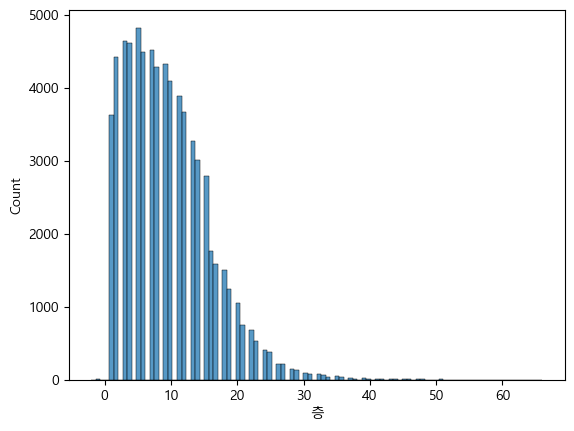

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font',family='Malgun Gothic')
sns.histplot(data=df, x='층', bins=100)
plt.xlabel('층') 
plt.show()

## 🟠 그룹 분석

9. 구별 거래금액의 평균, 최대값, 최소값을 구하시오.  


In [48]:
df.groupby('구')['거래금액'].agg(['mean', 'max', 'min']) 

,mean,max,min
구,,,
강남구,28.351920,190.00,1.3500
강동구,12.682820,33.00,0.7300
강북구,6.588776,12.70,0.7500
강서구,8.877549,23.00,0.7100
관악구,8.337241,17.00,0.8000
광진구,14.191279,39.00,1.1500
구로구,7.135536,21.00,0.6950
금천구,6.419462,14.05,0.8000
노원구,6.348460,16.00,0.8000


10.    계절별 거래금액의 평균, 최대값, 최소값을 구하시오.  

In [49]:
df.groupby('계절')['거래금액'].agg(['mean', 'max', 'min']) 

KeyError: '계절'

11. 구별 평형별 평균 거래금액을 구하시오.

In [55]:
df.groupby(['구','평형'])['거래금액'].mean()

구    평형   
강남구  10평대     17.485301
     10평이하     6.243352
     20평대     27.111405
     30평대     35.405208
     40평이상    56.482325
                ...    
중랑구  10평대      5.511101
     10평이하     2.332543
     20평대      7.616722
     30평대      9.602434
     40평이상     9.631667
Name: 거래금액, Length: 124, dtype: float64


## 🔵 시각화

12. 구별 평균 거래금액을 막대그래프로 표현하시오.

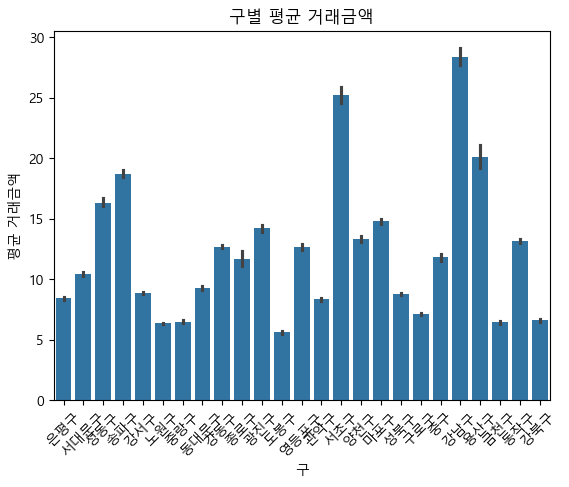

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('font',family='Malgun Gothic')
sns.barplot(data=df, x='구', y='거래금액') #barplot은 평균이 기본값

plt.title('구별 평균 거래금액')
plt.xlabel('구') 
plt.ylabel('평균 거래금액') 
plt.xticks(rotation=45)
plt.show()

13. 전용면적과 거래금액의 관계를 산점도로 표현하시오.

<Axes: xlabel='전용면적', ylabel='거래금액'>

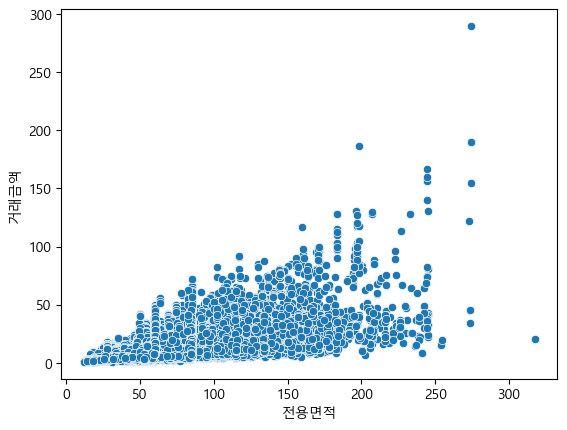

In [59]:
import seaborn as sns
sns.scatterplot(data=df, x='전용면적', y='거래금액')

14. 평형별 거래금액 분포를 박스플롯으로 표현하시오.

<Axes: xlabel='평형', ylabel='거래금액'>

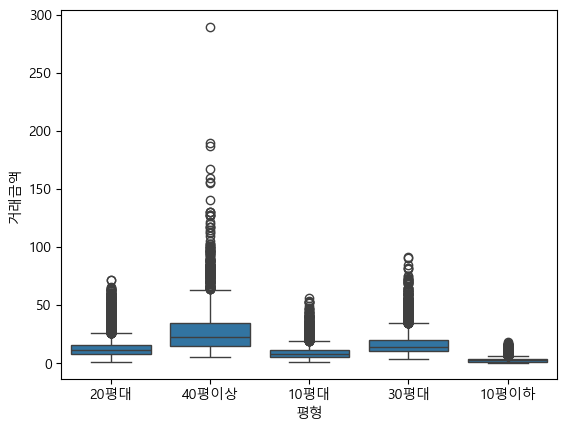

In [60]:
import seaborn as sns
sns.boxplot(data=df, x='평형', y='거래금액')

## 🔴 시간 분석

15. 요일별 거래 건수를 구하시오.

In [63]:
df.groupby('계약요일')['층'].count()

계약요일
금    12436
목     9861
수    10496
월     8803
일     3633
토    16718
화     9722
Name: 층, dtype: int64

16. 요일별 평균 거래금액을 구하시오.

In [64]:
df.groupby('계약요일')['거래금액'].mean()

계약요일
금    12.394864
목    11.947082
수    11.822990
월    11.808413
일    11.606726
토    11.727544
화    12.120810
Name: 거래금액, dtype: float64

17. 날짜별 거래 건수 추이를 확인하시오.

## 🟣 심화 분석

18. 거래 건수가 가장 많은 구 TOP 5를 구하시오.

19. 거래금액이 가장 높은 상위 10건을 조회하시오.

20. 강남3구+용산구와 그외지역의 거래건수,평균거래가격 를 출력하세요.